# Chapter 127 — Linear Combination

> **Prerequisites:** Vector Addition (ch125), Scalar Multiplication (ch126)
> **You will learn:**
> - The definition of a linear combination of vectors
> - Why linear combinations are the fundamental operation of linear algebra
> - How to compute them efficiently with NumPy
> - Applications: interpolation, weighted averages, and color mixing

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **linear combination** of vectors $\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k$ is any vector of the form:

$$c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_k \mathbf{v}_k$$

where $c_1, \ldots, c_k$ are scalars called **coefficients** or **weights**.

This is simply scaling each vector and adding the results. But the concept is vastly more important than it sounds. Almost every operation in linear algebra — matrix-vector multiplication, projections, regression, neural network layers — is ultimately a linear combination.

**Common misconception:** A linear combination does not require the vectors to be linearly independent, nor the coefficients to sum to 1. Both are special cases.

---

## 2. Intuition & Mental Models

**Color model:** RGB colors are linear combinations of the basis colors red, green, blue. The color (255, 128, 0) is $255 \cdot \mathbf{e}_r + 128 \cdot \mathbf{e}_g + 0 \cdot \mathbf{e}_b$.

**Mixing model:** Imagine mixing paints. Each paint is a vector (its color). A linear combination is a recipe: "3 parts this, 1 part that." The result is a new paint.

**Coordinate model:** Every vector in ℝⁿ is a linear combination of the standard basis vectors: $\mathbf{v} = v_1 \mathbf{e}_1 + v_2 \mathbf{e}_2 + \cdots + v_n \mathbf{e}_n$. You use this every time you write coordinates.

Recall from ch126 (Scalar Multiplication): the scaling step. Recall from ch125 (Vector Addition): the summing step. A linear combination is both, combined.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_1940\3657564691.py:54: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1940\3657564691.py:54: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


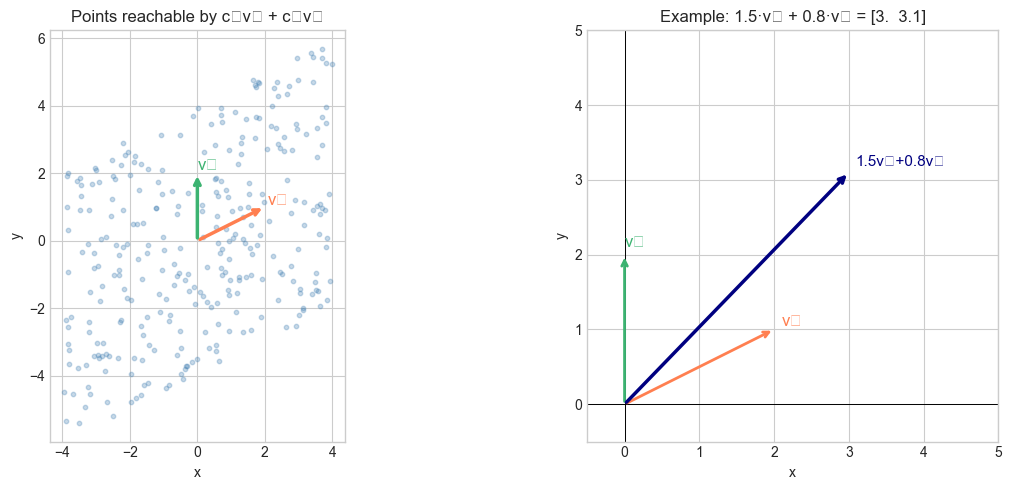

In [1]:
# --- Visualization: Linear combinations of two vectors ---
# Show what region is reachable by varying c1 and c2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

v1 = np.array([2.0, 1.0])
v2 = np.array([0.0, 2.0])

# Sample many coefficient pairs and plot the resulting combinations
np.random.seed(0)
N = 300
c1_vals = np.random.uniform(-2, 2, N)
c2_vals = np.random.uniform(-2, 2, N)

# Each row: c1*v1 + c2*v2
points = np.outer(c1_vals, v1) + np.outer(c2_vals, v2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left: scatter of reachable points ----
ax = axes[0]
ax.scatter(points[:, 0], points[:, 1], alpha=0.3, s=10, color='steelblue')
ax.annotate('', xy=v1, xytext=[0, 0],
            arrowprops=dict(arrowstyle='->', color='coral', lw=2.5))
ax.annotate('', xy=v2, xytext=[0, 0],
            arrowprops=dict(arrowstyle='->', color='mediumseagreen', lw=2.5))
ax.text(*v1*1.05, 'v₁', color='coral', fontsize=12)
ax.text(*v2*1.05, 'v₂', color='mediumseagreen', fontsize=12)
ax.set_title('Points reachable by c₁v₁ + c₂v₂')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

# ---- Right: specific example c1=1.5, c2=0.8 ----
ax = axes[1]
C1, C2 = 1.5, 0.8
result = C1 * v1 + C2 * v2

for vec, label, color in [(v1, 'v₁', 'coral'), (v2, 'v₂', 'mediumseagreen')]:
    ax.annotate('', xy=vec, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(*vec*1.05, label, color=color, fontsize=12)

ax.annotate('', xy=result, xytext=[0, 0],
            arrowprops=dict(arrowstyle='->', color='navy', lw=2.5))
ax.text(*result*1.03, f'{C1}v₁+{C2}v₂', color='navy', fontsize=11)

ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 5)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title(f'Example: {C1}·v₁ + {C2}·v₂ = {result}')
ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Definition.** Given vectors $\mathbf{v}_1, \ldots, \mathbf{v}_k \in \mathbb{R}^n$ and scalars $c_1, \ldots, c_k \in \mathbb{R}$, their linear combination is:

$$\mathbf{w} = \sum_{j=1}^k c_j \mathbf{v}_j$$

**Special cases:**
- **Affine combination:** $\sum c_j = 1$ — the result lies on the affine hull (e.g., the line or plane through the vectors)
- **Convex combination:** $c_j \geq 0$ and $\sum c_j = 1$ — the result lies *between* the vectors (interpolation)
- **Span:** the set of all possible linear combinations of $\mathbf{v}_1, \ldots, \mathbf{v}_k$ is their *span* *(ch140)*

**As matrix-vector product:** if the vectors are columns of a matrix $A$, then $A\mathbf{c}$ computes the linear combination — this is the fundamental insight connecting vectors to matrices *(ch151–153, Part VI)*.

In [2]:
# --- Mathematical Formulation: linear_combination ---
import numpy as np

def linear_combination(vectors, coefficients):
    """
    Compute the linear combination sum(c_j * v_j).

    Args:
        vectors: list of ndarrays, each shape (n,)
        coefficients: list of floats, same length

    Returns:
        ndarray shape (n,)
    """
    vectors = [np.asarray(v, float) for v in vectors]
    n = vectors[0].shape[0]
    result = np.zeros(n)
    for c, v in zip(coefficients, vectors):
        result = result + c * v
    return result


v1 = np.array([1.0, 0.0, 0.0])  # e1
v2 = np.array([0.0, 1.0, 0.0])  # e2
v3 = np.array([0.0, 0.0, 1.0])  # e3

# Any vector is a linear combination of basis vectors
target = np.array([3.0, -2.0, 5.0])
result = linear_combination([v1, v2, v3], [3, -2, 5])
print("target:", target)
print("result:", result)
print("match: ", np.allclose(target, result))

# Convex combination (coefficients sum to 1): midpoint
a = np.array([0.0, 0.0])
b = np.array([4.0, 2.0])
midpoint = linear_combination([a, b], [0.5, 0.5])
print("\nMidpoint of a and b:", midpoint)

target: [ 3. -2.  5.]
result: [ 3. -2.  5.]
match:  True

Midpoint of a and b: [2. 1.]


## 5. Python Implementation

In [3]:
# --- Implementation: Efficient vectorized linear combination ---
import numpy as np

def linear_combination_fast(V, c):
    """
    Compute linear combination using matrix-vector product.
    Equivalent to sum(c[j] * V[j] for all j).

    Args:
        V: ndarray shape (k, n) — k vectors of dimension n, one per row
        c: ndarray shape (k,)   — k coefficients

    Returns:
        ndarray shape (n,)
    """
    V = np.asarray(V, dtype=float)
    c = np.asarray(c, dtype=float)
    # V.T @ c is equivalent to sum(c[j] * V[j])
    return V.T @ c


def interpolate(u, v, t):
    """
    Linear interpolation between u (t=0) and v (t=1).
    This is a convex combination: (1-t)*u + t*v.

    Args:
        u, v: ndarray shape (n,)
        t: float in [0, 1]

    Returns:
        ndarray shape (n,)
    """
    return (1 - t) * np.asarray(u, float) + t * np.asarray(v, float)


# Test
V = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
c = np.array([2.0, -1.0, 0.5])
print("Linear combination:", linear_combination_fast(V, c))

u = np.array([0.0, 0.0])
v = np.array([10.0, 5.0])
for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
    pt = interpolate(u, v, t)
    print(f"t={t:.2f}  →  {pt}")

Linear combination: [ 2.5 -0.5]
t=0.00  →  [0. 0.]
t=0.25  →  [2.5  1.25]
t=0.50  →  [5.  2.5]
t=0.75  →  [7.5  3.75]
t=1.00  →  [10.  5.]


## 6. Experiments

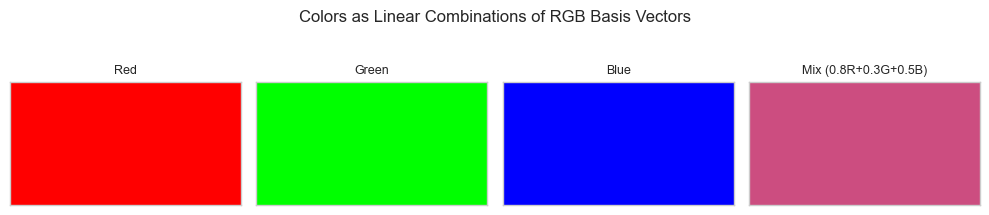

Mixed color (RGB): [0.8 0.3 0.5]


In [4]:
# --- Experiment 1: Color mixing as linear combination ---
# Hypothesis: RGB colors are linear combinations of basis colors.
# Try changing: the coefficients to mix different colors.
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

red   = np.array([1.0, 0.0, 0.0])
green = np.array([0.0, 1.0, 0.0])
blue  = np.array([0.0, 0.0, 1.0])

# Coefficients (must be in [0,1] for valid RGB)
C_RED   = 0.8  # <-- modify
C_GREEN = 0.3  # <-- modify
C_BLUE  = 0.5  # <-- modify

mixed = np.clip(C_RED * red + C_GREEN * green + C_BLUE * blue, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(10, 2))
for ax, color, title in zip(axes,
    [red, green, blue, mixed],
    ['Red', 'Green', 'Blue', f'Mix ({C_RED:.1f}R+{C_GREEN:.1f}G+{C_BLUE:.1f}B)']):
    ax.set_facecolor(color)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Colors as Linear Combinations of RGB Basis Vectors', y=1.05)
plt.tight_layout()
plt.show()
print("Mixed color (RGB):", mixed)

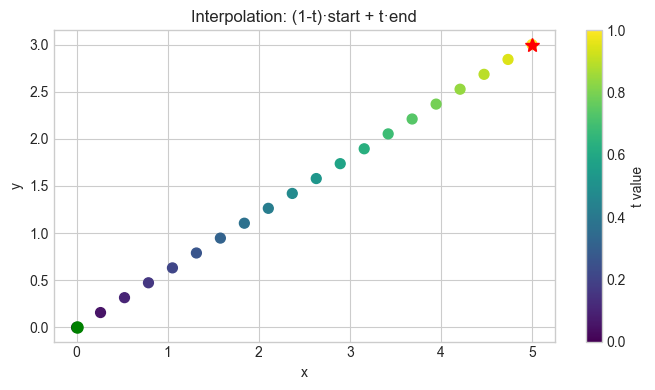

In [5]:
# --- Experiment 2: Interpolation path ---
# Hypothesis: varying t from 0 to 1 traces a straight line between two points.
# Try changing: T_VALUES to non-uniform spacings.
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

start = np.array([0.0, 0.0])
end   = np.array([5.0, 3.0])

T_VALUES = np.linspace(0, 1, 20)  # <-- modify: try np.logspace, custom values

pts = np.array([(1-t)*start + t*end for t in T_VALUES])

plt.figure(figsize=(7, 4))
plt.scatter(pts[:, 0], pts[:, 1], c=T_VALUES, cmap='viridis', s=50)
plt.colorbar(label='t value')
plt.plot(*start, 'go', markersize=8); plt.plot(*end, 'r*', markersize=10)
plt.title('Interpolation: (1-t)·start + t·end')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()

## 7. Exercises

**Easy 1.** Compute $2\mathbf{u} - 3\mathbf{v} + \mathbf{w}$ for **u** = (1,0,2), **v** = (3,1,-1), **w** = (0,4,0). *(Expected: (-7, 1, 7))*

**Easy 2.** Express the vector (5, 3) as a linear combination of (1, 0) and (0, 1). Then express it as a linear combination of (1, 1) and (1, -1). *Hint for the second: solve the 2×2 system.*

**Medium 1.** Implement `weighted_average(vectors, weights)` where weights are non-negative and sum to 1. Apply it to compute the centroid of 5 random 2D points.

**Medium 2.** Generate 50 interpolation frames between two 3D points **p** = (0,0,0) and **q** = (1,2,3). Plot the trajectory in 3D using `ax = fig.add_subplot(projection='3d')`.

**Hard.** Show that *every* vector in ℝ³ can be written as a linear combination of **v₁** = (1,1,0), **v₂** = (1,0,1), **v₃** = (0,1,1). Find the coefficients for **w** = (3,5,1). *(Challenge: solve the 3×3 linear system — relates to ch160, Gaussian Elimination)*

---

## 8. Mini Project

Coefficients: [0.4566474  0.35260116 0.53757225]
Approximation: [0.5 0.4 0.6]
Target:        [0.5 0.4 0.6]
Error:         3.3766115072321297e-16


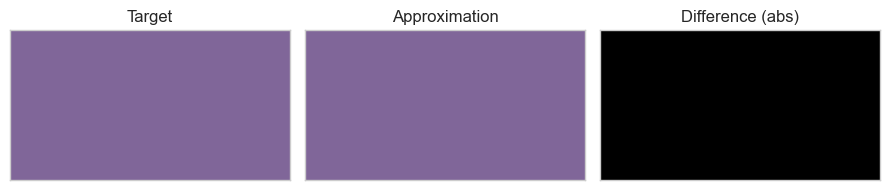

In [6]:
# --- Mini Project: Palette Mixer ---
# Problem: Given a target RGB color, find the closest mixture of 3 palette colors.
# This is a constrained linear combination problem.
# Task: implement find_mixture() using least squares, visualize result.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Palette: 3 paint colors (normalized RGB)
palette = np.array([
    [0.9, 0.1, 0.1],  # red-ish
    [0.1, 0.7, 0.2],  # green-ish
    [0.1, 0.2, 0.9],  # blue-ish
])

target = np.array([0.5, 0.4, 0.6])  # the color we want to approximate

def find_mixture(palette, target):
    """
    Find coefficients c such that palette.T @ c ≈ target.
    Use np.linalg.lstsq to find least-squares solution.

    Args:
        palette: ndarray shape (k, 3) — k paint colors
        target:  ndarray shape (3,)   — target RGB

    Returns:
        c: ndarray shape (k,) — mixture coefficients
        approximation: ndarray shape (3,) — achieved color
    """
    # palette.T @ c = target
    c, _, _, _ = np.linalg.lstsq(palette.T, target, rcond=None)
    approx = palette.T @ c
    return c, np.clip(approx, 0, 1)


coefficients, approximation = find_mixture(palette, target)
print("Coefficients:", coefficients)
print("Approximation:", approximation)
print("Target:       ", target)
print("Error:        ", np.linalg.norm(target - approximation))

fig, axes = plt.subplots(1, 3, figsize=(9, 2))
for ax, color, title in zip(axes,
    [target, approximation, np.abs(target - approximation)],
    ['Target', 'Approximation', 'Difference (abs)']):
    ax.set_facecolor(color)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 9. Summary & Connections

- A linear combination is a sum of scaled vectors: $\sum c_j \mathbf{v}_j$.
- Special cases: convex combination ($c_j \geq 0$, $\sum c_j = 1$) stays between the vectors.
- The set of all linear combinations of a set of vectors is their **span** *(formalized in ch140)*.
- The matrix-vector product $A\mathbf{c}$ computes a linear combination of the columns of $A$.

**Backward connection:** This combines ch125 (addition) and ch126 (scaling) into the central operation of all linear algebra.

**Forward connections:**
- This will reappear in ch140 — Span, where we ask: what is the set of all possible linear combinations of a given set of vectors?
- This will reappear in ch153 — Matrix Multiplication (Part VI), where every column of $AB$ is a linear combination of columns of $A$.
- This will reappear in ch177 — Linear Layers in Deep Learning, where a neural network layer computes a learned linear combination of inputs.